[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/colab-version/L01/L01_beam_optimization.ipynb)

# Cantilever Beam Design Optimization
### MECH 559 — Systems Optimization
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

This notebook illustrates analytical beam design optimization examples introduced in Lecture 01.

**Contents:**
1. Problem setup and analysis models
2. 1D optimization (design variable: $h$, parameter: $b$)
3. Parametric study and Pareto front (1D)
4. 2D optimization (design variables: $h$ and $b$)
5. Pareto front via $\varepsilon$-constraint method (2D)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar

plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})

---
## 1. Problem Setup and Analysis Models

Consider a **cantilever beam** with rectangular cross-section $b \times h$, loaded by a tip force $P$.

| Symbol | Meaning | Role |
|--------|---------|------|
| $h$ | cross-section height | **design variable** |
| $b$ | cross-section width | parameter (or 2nd design variable in 2D) |
| $L$ | beam length | parameter |
| $P$ | tip load | parameter |
| $\rho$ | material density | parameter |
| $E$ | Young's modulus | parameter |

**Functions of interest** (using $I = bh^3/12$):

$$W(h,b) = \rho b h L$$

$$\sigma_{\max}(h,b) = \frac{6PL}{bh^2}$$

$$\delta_{\text{tip}}(h,b) = \frac{4PL^3}{Ebh^3}$$

In [2]:
# ── Physical parameters ──────────────────────────────────────────────────────
P   = 1000.0   # tip load [N]
L   = 1.0      # beam length [m]
rho = 7850.0   # density of steel [kg/m³]
E   = 200e9    # Young's modulus of steel [Pa]
b0  = 0.05     # fixed width for 1D case [m]

# ── Analysis models ──────────────────────────────────────────────────────────
def mass(h, b):
    return rho * b * h * L

def sigma_max(h, b):
    return 6 * P * L / (b * h**2)

def delta_tip(h, b):
    return 4 * P * L**3 / (E * b * h**3)

# Quick sanity check
h_test, b_test = 0.05, 0.05
print(f"At h={h_test:.3f} m, b={b_test:.3f} m:")
print(f"  W           = {mass(h_test, b_test):.3f} kg")
print(f"  σ_max       = {sigma_max(h_test, b_test)/1e6:.2f} MPa")
print(f"  δ_tip       = {delta_tip(h_test, b_test)*1e3:.4f} mm")

At h=0.050 m, b=0.050 m:
  W           = 19.625 kg
  σ_max       = 48.00 MPa
  δ_tip       = 3.2000 mm


---
## 2. 1D Optimization

**Design variable:** $h$ (height). Width $b = b_0$ is a fixed parameter.

**Problem P1:**
$$\min_{h} \; W(h;\, b_0,L,\rho) \qquad \text{subject to} \quad \sigma_{\max}(h;\, b_0,L,P) \leq \sigma_y$$

### Analytical solution

Since $W = \rho b_0 h L$ is strictly increasing in $h$, and $\sigma_{\max} = 6PL/(b_0 h^2)$ is strictly decreasing in $h$, the constraint will always be **active** at the optimum:

$$\sigma_{\max}(h^*) = \sigma_y \;\Longrightarrow\; h^* = \sqrt{\frac{6PL}{b_0 \,\sigma_y}}$$

$$W^* = \rho b_0 L \sqrt{\frac{6PL}{b_0 \,\sigma_y}} = \rho L \sqrt{\frac{6PL\, b_0}{\sigma_y}}$$

In [3]:
sigma_y = 250e6   # allowable stress [Pa] (example: mild steel yield stress)

# ── Analytical optimum ───────────────────────────────────────────────────────
h_star = np.sqrt(6 * P * L / (b0 * sigma_y))
W_star = mass(h_star, b0)

print(f"Allowable stress σ_y = {sigma_y/1e6:.0f} MPa")
print(f"Optimal height   h*  = {h_star*1e3:.4f} mm")
print(f"Optimal mass     W*  = {W_star:.6f} kg")
print(f"Constraint check: σ_max(h*) = {sigma_max(h_star, b0)/1e6:.2f} MPa  (should equal σ_y)")

Allowable stress σ_y = 250 MPa
Optimal height   h*  = 21.9089 mm
Optimal mass     W*  = 8.599244 kg
Constraint check: σ_max(h*) = 250.00 MPa  (should equal σ_y)


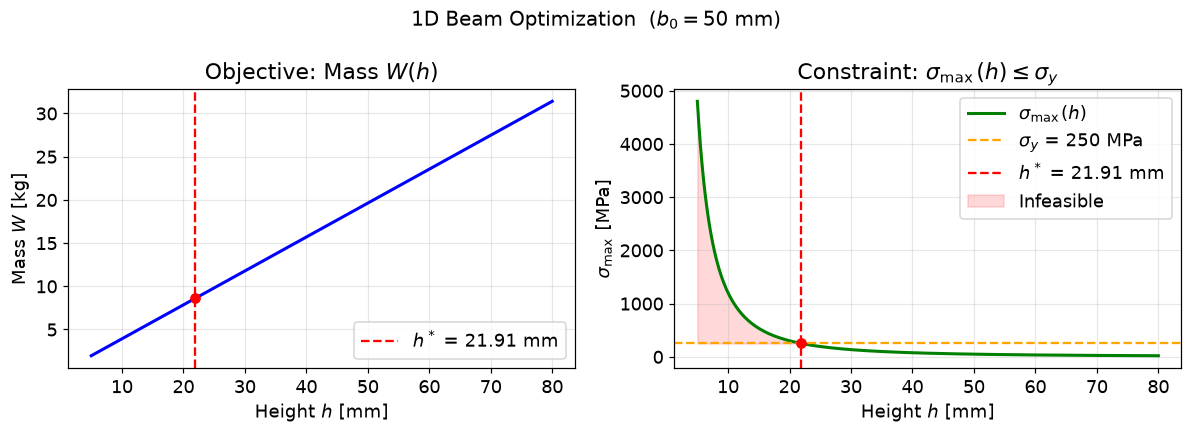

In [4]:
# ── Plot W and σ_max vs h ─────────────────────────────────────────────────────
h_vals = np.linspace(0.005, 0.08, 300)
W_vals     = mass(h_vals, b0)
sigma_vals = sigma_max(h_vals, b0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: mass vs h
ax = axes[0]
ax.plot(h_vals * 1e3, W_vals, 'b-', lw=2)
ax.axvline(h_star * 1e3, color='r', ls='--', label=f'$h^*$ = {h_star*1e3:.2f} mm')
ax.scatter([h_star * 1e3], [W_star], color='r', zorder=5)
ax.set_xlabel('Height $h$ [mm]')
ax.set_ylabel('Mass $W$ [kg]')
ax.set_title('Objective: Mass $W(h)$')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: stress vs h with constraint bound
ax = axes[1]
ax.plot(h_vals * 1e3, sigma_vals / 1e6, 'g-', lw=2, label='$\\sigma_{\\max}(h)$')
ax.axhline(sigma_y / 1e6, color='orange', ls='--', lw=1.5, label=f'$\\sigma_y$ = {sigma_y/1e6:.0f} MPa')
ax.axvline(h_star * 1e3, color='r', ls='--', label=f'$h^*$ = {h_star*1e3:.2f} mm')
ax.scatter([h_star * 1e3], [sigma_y / 1e6], color='r', zorder=5)
ax.fill_between(h_vals * 1e3, sigma_vals / 1e6, sigma_y / 1e6,
                where=(sigma_vals > sigma_y), alpha=0.15, color='red', label='Infeasible')
ax.set_xlabel('Height $h$ [mm]')
ax.set_ylabel('$\\sigma_{\\max}$ [MPa]')
ax.set_title('Constraint: $\\sigma_{\\max}(h) \\leq \\sigma_y$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'1D Beam Optimization  ($b_0 = {b0*1e3:.0f}$ mm)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Parametric Study and Pareto Front (1D)

We solve **P1** for 60 values of the constraint bound $\sigma_y$ and plot the resulting pairs
$(W^*_i, \sigma_{y,i})$. Because the constraint is always active, $\sigma_{\max}(h^*_i) = \sigma_{y,i}$,
so the curve traces the **Pareto front** between minimizing $W$ and minimizing $\sigma_{\max}$.

> **Key insight:** A single-objective problem with an active inequality constraint is
> essentially a multi-objective problem — its solution is *one* point on the Pareto front.

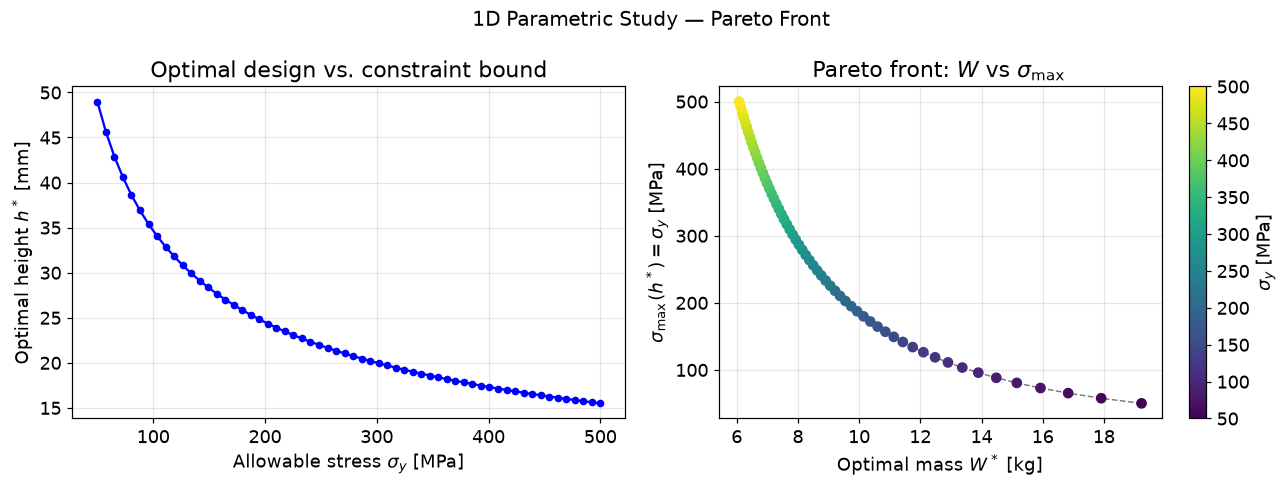

Constraint activity check:
  Max |σ_max(h*) - σ_y| = 1.19e-07 Pa  (should be ≈ 0)


In [5]:
n_pts  = 60
sigma_y_vals = np.linspace(50e6, 500e6, n_pts)   # sweep σ_y from 50 to 500 MPa

h_opt  = np.sqrt(6 * P * L / (b0 * sigma_y_vals))
W_opt  = mass(h_opt, b0)
# constraint is always active, so σ_max = σ_y at each optimum
sigma_opt = sigma_max(h_opt, b0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: optimal h* vs σ_y
ax = axes[0]
ax.plot(sigma_y_vals / 1e6, h_opt * 1e3, 'b-o', ms=4)
ax.set_xlabel('Allowable stress $\\sigma_y$ [MPa]')
ax.set_ylabel('Optimal height $h^*$ [mm]')
ax.set_title('Optimal design vs. constraint bound')
ax.grid(True, alpha=0.3)

# Right: Pareto front  W* vs σ_max*
ax = axes[1]
sc = ax.scatter(W_opt, sigma_opt / 1e6, c=sigma_y_vals / 1e6,
                cmap='viridis', zorder=5)
ax.plot(W_opt, sigma_opt / 1e6, 'k--', lw=1, alpha=0.5)
plt.colorbar(sc, ax=ax, label='$\\sigma_y$ [MPa]')
ax.set_xlabel('Optimal mass $W^*$ [kg]')
ax.set_ylabel('$\\sigma_{\\max}(h^*) = \\sigma_y$ [MPa]')
ax.set_title('Pareto front: $W$ vs $\\sigma_{\\max}$')
ax.grid(True, alpha=0.3)

plt.suptitle('1D Parametric Study — Pareto Front', fontsize=13)
plt.tight_layout()
plt.show()

print("Constraint activity check:")
print(f"  Max |σ_max(h*) - σ_y| = {np.max(np.abs(sigma_opt - sigma_y_vals)):.2e} Pa  (should be ≈ 0)")

---
## 4. 2D Optimization

**Design variables:** $\mathbf{x} = [h,\, b]^\top$ (both height and width are optimized).

**Problem P2:**
$$\min_{h,b} \; W(h,b) = \rho b h L$$
$$\text{subject to} \quad \sigma_{\max}(h,b) = \frac{6PL}{bh^2} \leq \sigma_y$$
$$\qquad\qquad\qquad \delta_{\text{tip}}(h,b) = \frac{4PL^3}{Ebh^3} \leq \delta_{\max}$$
$$\qquad\qquad\qquad h_{\min} \leq h \leq h_{\max}, \quad b_{\min} \leq b \leq b_{\max}$$

### Analytical observations

With only one constraint (stress), the problem is underdetermined with two variables —
the feasible set is a curve and $W \to 0$ as $b \to 0, h \to \infty$.
Side constraints (bounds on $h$ and $b$) or a second active constraint (deflection) are needed to obtain a finite optimum.

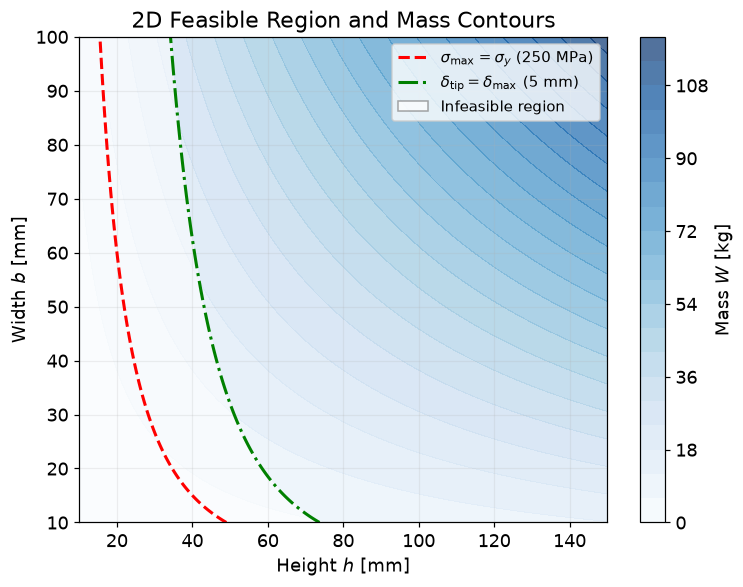

In [6]:
# ── 2D problem parameters ────────────────────────────────────────────────────
sigma_y_2d  = 250e6     # allowable stress [Pa]
delta_max   = 5e-3      # max tip deflection [m]  (5 mm)
h_min, h_max = 0.01, 0.15   # bounds on h [m]
b_min, b_max = 0.01, 0.10   # bounds on b [m]

# ── Feasible region visualization ────────────────────────────────────────────
h_grid = np.linspace(h_min, h_max, 400)
b_grid = np.linspace(b_min, b_max, 400)
H, B   = np.meshgrid(h_grid, b_grid)

W_grid     = mass(H, B)
Sigma_grid = sigma_max(H, B)
Delta_grid = delta_tip(H, B)

feasible = (Sigma_grid <= sigma_y_2d) & (Delta_grid <= delta_max)

fig, ax = plt.subplots(figsize=(7, 5.5))

# Filled contour of mass
cs = ax.contourf(H * 1e3, B * 1e3, W_grid, levels=20, cmap='Blues', alpha=0.7)
plt.colorbar(cs, ax=ax, label='Mass $W$ [kg]')

# Constraint boundaries
ax.contour(H * 1e3, B * 1e3, Sigma_grid / 1e6, levels=[sigma_y_2d / 1e6],
           colors='red', linewidths=2, linestyles='--')
ax.contour(H * 1e3, B * 1e3, Delta_grid * 1e3, levels=[delta_max * 1e3],
           colors='green', linewidths=2, linestyles='-.')

# Infeasible overlay
ax.contourf(H * 1e3, B * 1e3, feasible.astype(float),
            levels=[-0.5, 0.5], colors='white', alpha=0.55)

# Proxy artists for legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elems = [
    Line2D([0],[0], color='red',   lw=2, ls='--', label=f'$\\sigma_{{\\max}} = \\sigma_y$ ({sigma_y_2d/1e6:.0f} MPa)'),
    Line2D([0],[0], color='green', lw=2, ls='-.', label=f'$\\delta_{{\\mathrm{{tip}}}} = \\delta_{{\\max}}$ ({delta_max*1e3:.0f} mm)'),
    Patch(facecolor='white', edgecolor='gray', alpha=0.7, label='Infeasible region'),
]
ax.legend(handles=legend_elems, loc='upper right', fontsize=10)
ax.set_xlabel('Height $h$ [mm]')
ax.set_ylabel('Width $b$ [mm]')
ax.set_title('2D Feasible Region and Mass Contours')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [7]:
# ── Numerical 2D optimum via scipy ───────────────────────────────────────────
def objective(x):
    h, b = x
    return mass(h, b)

constraints = [
    {'type': 'ineq', 'fun': lambda x: sigma_y_2d - sigma_max(x[0], x[1])},
    {'type': 'ineq', 'fun': lambda x: delta_max  - delta_tip(x[0], x[1])},
]
bounds = [(h_min, h_max), (b_min, b_max)]

x0 = [0.05, 0.05]   # initial guess
result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)

h_opt2d, b_opt2d = result.x
print("2D Numerical Optimum:")
print(f"  h* = {h_opt2d*1e3:.3f} mm,  b* = {b_opt2d*1e3:.3f} mm")
print(f"  W* = {mass(h_opt2d, b_opt2d):.6f} kg")
print(f"  σ_max(x*) = {sigma_max(h_opt2d, b_opt2d)/1e6:.2f} MPa  (bound: {sigma_y_2d/1e6:.0f} MPa)")
print(f"  δ_tip(x*) = {delta_tip(h_opt2d, b_opt2d)*1e3:.4f} mm   (bound: {delta_max*1e3:.0f} mm)")
print(f"  Optimizer exit: {result.message}")

2D Numerical Optimum:
  h* = 73.681 mm,  b* = 10.000 mm
  W* = 5.783929 kg
  σ_max(x*) = 110.52 MPa  (bound: 250 MPa)
  δ_tip(x*) = 5.0000 mm   (bound: 5 mm)
  Optimizer exit: Optimization terminated successfully


---
## 5. Pareto Front via $\varepsilon$-Constraint Method (2D)

We treat **$W$ (mass) and $\delta_{\text{tip}}$ (deflection)** as competing objectives.
The $\varepsilon$-constraint method fixes the deflection bound $\varepsilon_k$ and minimizes mass:

$$\min_{h,b} \; W(h,b) \quad \text{subject to} \quad \delta_{\text{tip}}(h,b) \leq \varepsilon_k, \quad \sigma_{\max}(h,b) \leq \sigma_y, \quad \text{side constraints}$$

As $\varepsilon_k$ decreases (tighter deflection limit), the beam needs more material — mass increases.
Sweeping $\varepsilon_k$ traces the full **Pareto front** between minimizing $W$ and minimizing $\delta_{\text{tip}}$.

In [8]:
n_pareto = 60
# Sweep δ_max from a tight (0.5 mm) to a relaxed (8 mm) deflection bound
delta_eps_vals = np.linspace(0.5e-3, 8e-3, n_pareto)  # ε_k in [m]

W_pareto     = []
sigma_pareto = []
delta_pareto = []
x_pareto     = []

for eps_k in delta_eps_vals:
    cons = [
        {'type': 'ineq', 'fun': lambda x, e=eps_k: e - delta_tip(x[0], x[1])},
        {'type': 'ineq', 'fun': lambda x: sigma_y_2d - sigma_max(x[0], x[1])},
    ]
    # try multiple starting points for robustness
    best = None
    for x0_try in [[0.08, 0.03], [0.12, 0.02], [0.05, 0.06]]:
        res = minimize(objective, x0_try, method='SLSQP',
                       bounds=bounds, constraints=cons,
                       options={'ftol': 1e-12, 'maxiter': 1000})
        if res.success and (best is None or res.fun < best.fun):
            best = res
    if best is not None and best.success:
        h_k, b_k = best.x
        W_pareto.append(mass(h_k, b_k))
        sigma_pareto.append(sigma_max(h_k, b_k))
        delta_pareto.append(delta_tip(h_k, b_k))
        x_pareto.append(best.x)

W_pareto     = np.array(W_pareto)
sigma_pareto = np.array(sigma_pareto)
delta_pareto = np.array(delta_pareto)
x_pareto     = np.array(x_pareto)

print(f"Computed {len(W_pareto)} Pareto-optimal solutions out of {n_pareto} ε values.")
print(f"  W range:      [{W_pareto.min():.2f}, {W_pareto.max():.2f}] kg")
print(f"  δ_tip range:  [{delta_pareto.min()*1e3:.3f}, {delta_pareto.max()*1e3:.3f}] mm")

Computed 38 Pareto-optimal solutions out of 60 ε values.
  W range:      [4.95, 9.86] kg
  δ_tip range:  [1.008, 8.000] mm


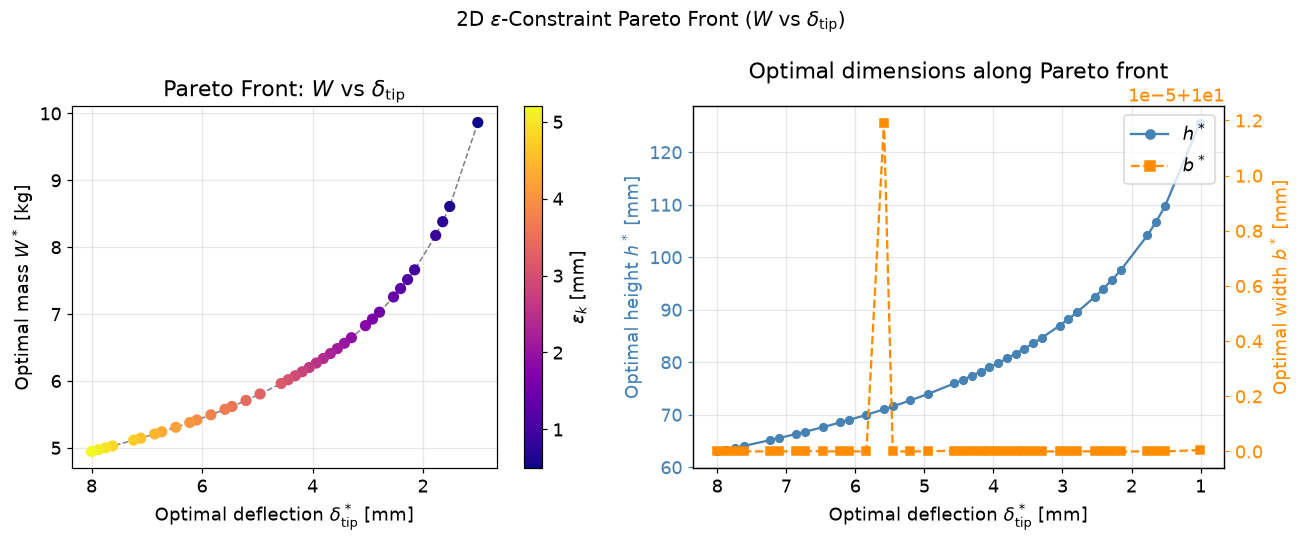

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Pareto front — W* vs δ_tip*
ax = axes[0]
sc = ax.scatter(delta_pareto * 1e3, W_pareto,
                c=delta_eps_vals[:len(W_pareto)] * 1e3, cmap='plasma', zorder=5, s=40)
ax.plot(delta_pareto * 1e3, W_pareto, 'k--', lw=1, alpha=0.5)
plt.colorbar(sc, ax=ax, label='$\\varepsilon_k$ [mm]')
ax.set_xlabel('Optimal deflection $\\delta_{\\mathrm{tip}}^*$ [mm]')
ax.set_ylabel('Optimal mass $W^*$ [kg]')
ax.set_title('Pareto Front: $W$ vs $\\delta_{\\mathrm{tip}}$')
ax.invert_xaxis()  # tighter deflection → right side is 'better' in deflection
ax.grid(True, alpha=0.3)

# Right: optimal h* along the Pareto front
ax = axes[1]
ax.plot(delta_pareto * 1e3, x_pareto[:, 0] * 1e3, 'o-', color='steelblue', ms=5)
ax2r = ax.twinx()
ax2r.plot(delta_pareto * 1e3, x_pareto[:, 1] * 1e3, 's--', color='darkorange', ms=5)
ax2r.set_ylabel('Optimal width $b^*$ [mm]', color='darkorange')
ax2r.tick_params(axis='y', colors='darkorange')
ax.set_xlabel('Optimal deflection $\\delta_{\\mathrm{tip}}^*$ [mm]')
ax.set_ylabel('Optimal height $h^*$ [mm]', color='steelblue')
ax.tick_params(axis='y', colors='steelblue')
ax.invert_xaxis()
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],color='steelblue',marker='o',label='$h^*$'),
                   Line2D([0],[0],color='darkorange',marker='s',ls='--',label='$b^*$')],
          loc='upper right')
ax.set_title('Optimal dimensions along Pareto front')
ax.grid(True, alpha=0.3)

plt.suptitle('2D $\\varepsilon$-Constraint Pareto Front ($W$ vs $\\delta_{\\mathrm{tip}}$)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

| | 1D problem | 2D problem |
|---|---|---|
| Design variables | $h$ | $h$, $b$ |
| Constraints | stress only | stress + deflection |
| Analytical optimum | $h^* = \sqrt{6PL/(b_0\sigma_y)}$ | deflection active → $b^* = b_{\min}$, $h^*$ varies |
| Constraint activity | stress always active | deflection active; stress inactive |

**Key takeaways from Lecture 01:**
- The optimal design $\mathbf{x}^*(\mathbf{p})$ depends on parameter values — it changes if parameters change.
- When a constraint is active, the single-objective problem is equivalent to **one point** on the Pareto front.
- A parametric study (sweeping $\sigma_y$ or $\delta_{\max}$) traces the full Pareto front.
- The $\varepsilon$-constraint method is one systematic way to generate Pareto-optimal solutions.
- **2D degeneracy observation:** minimizing mass subject to a deflection constraint drives $b$ to its lower
  bound ($b^* = b_{\min}$) because a tall, narrow section is the most material-efficient cross-section.
  The 2D problem therefore reduces to a 1D problem in $h$ alone — highlighting that problem structure
  and bound activity can reduce the effective dimensionality of an optimization problem.